<a href="https://colab.research.google.com/github/anothergrind/geomagnetic-storm-predictor/blob/main/cme_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) - Coronal Mass Ejections (CMEs)

## Project Context
Coronal Mass Ejections (CMEs) are massive bursts of solar wind and magnetic fields rising above the solar corona. They are the primary drivers of severe geomagnetic storms. This notebook explores the `cme_dataset.csv` to clean the features, analyze distributions (such as speed and half-angle), and prepare the data for integration into our geomagnetic storm predictor pipeline.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Data Loading and Initial Inspection
We will load the dataset and check its dimensions, column data types, and initial missing value counts.

In [4]:
# Adjust the path according to your repository structure
data_path = "cme_dataset.csv"

df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- Column Info ---")
print(df.info())

Dataset Shape: 4734 rows, 30 columns

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4734 entries, 0 to 4733
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cme_time                   4734 non-null   object 
 1   cme_speed_kms              4720 non-null   float64
 2   cme_half_angle_deg         4720 non-null   float64
 3   cme_latitude               4714 non-null   float64
 4   cme_longitude              4007 non-null   float64
 5   cme_type_num               4718 non-null   float64
 6   cme_id                     4734 non-null   int64  
 7   flare_class                3770 non-null   object 
 8   flare_class_num            3770 non-null   float64
 9   flare_log_peak_flux        3770 non-null   float64
 10  flare_duration_min         3770 non-null   float64
 11  flare_end_time_imputed     3770 non-null   float64
 12  has_flare                  4734 non-null   int

In [5]:
# Preview the first few records
df.head()

,cme_time,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude,cme_type_num,cme_id,flare_class,flare_class_num,flare_log_peak_flux,...,wind_density_mean,wind_pressure_mean,wind_efield_mean,wind_temp_mean,ctx_f107,ctx_sunspots,kp_max_post,storm,storm_attributed,storm_attributed_v2
0,2017-02-10 13:48:00,594.0,10.0,18.0,148.0,2.0,0,NaN,NaN,NaN,...,5.500000,2.005278,0.243889,70931.944444,72.027778,22.555556,2.3,0,0,0
1,2017-02-11 06:00:00,456.0,18.0,-1.0,93.0,1.0,1,NaN,NaN,NaN,...,4.745946,1.616486,0.265946,56423.216216,72.972973,23.486486,2.3,0,0,0
2,2017-02-15 03:09:00,405.0,12.0,16.0,-173.0,1.0,2,NaN,NaN,NaN,...,12.597222,2.053611,0.010000,18074.472222,72.833333,19.555556,4.3,0,0,0
3,2017-02-18 02:30:00,239.0,17.0,26.0,-110.0,1.0,3,B,1.0,-6.885685,...,6.983333,3.387500,0.509722,149947.583333,73.675000,13.583333,3.7,0,0,0
4,2017-02-18 07:24:00,492.0,27.0,4.0,88.0,1.0,4,NaN,NaN,NaN,...,6.444444,3.187778,0.266111,137876.500000,73.966667,13.444444,3.7,0,0,0


## 2. Data Cleaning & Preprocessing
Common tasks for space weather data include:
* Converting date/time columns to proper `datetime64` types.
* Handling placeholders for missing values (e.g., `-9999`, `NaN`, or empty strings).
* Extracting numerical components from categorical strings if needed.

In [6]:
# 1. Identify and handle missing data
print("Missing values per column:")
print(df.isnull().sum())

# 2. Convert time columns to datetime object
time_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"Converted {col} to datetime.")

# 3. Handle specific null flags (e.g., replacing standard space weather flags like -9999 with NaN)
df.replace(-9999, np.nan, inplace=True)

df.describe()

Missing values per column:
cme_time                       0
cme_speed_kms                 14
cme_half_angle_deg            14
cme_latitude                  20
cme_longitude                727
cme_type_num                  16
cme_id                         0
flare_class                  964
flare_class_num              964
flare_log_peak_flux          964
flare_duration_min           964
flare_end_time_imputed       964
has_flare                      0
wind_bz_mean                   0
wind_bz_min                    0
wind_bz_south_frac             0
wind_bz_strong_south_frac      0
wind_imf_mean                  0
wind_speed_mean                0
wind_speed_max                 0
wind_density_mean              0
wind_pressure_mean             0
wind_efield_mean               0
wind_temp_mean                 0
ctx_f107                       0
ctx_sunspots                   0
kp_max_post                    0
storm                          0
storm_attributed               0
storm_attributed

,cme_time,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude,cme_type_num,cme_id,flare_class_num,flare_log_peak_flux,flare_duration_min,...,wind_density_mean,wind_pressure_mean,wind_efield_mean,wind_temp_mean,ctx_f107,ctx_sunspots,kp_max_post,storm,storm_attributed,storm_attributed_v2
count,4734,4720.000000,4720.000000,4714.000000,4007.000000,4718.000000,4734.000000,3770.000000,3770.000000,3770.000000,...,4734.000000,4734.000000,4734.000000,4734.000000,4734.000000,4734.000000,4734.000000,4734.000000,4734.000000,4734.000000
mean,2022-12-19 12:16:30.583016448,525.595788,25.763242,-4.213449,2.483304,1.487071,2366.500000,2.096552,-5.395643,20.720159,...,6.298060,2.027730,0.031689,99053.197484,148.019195,107.222816,3.952134,0.227926,0.029573,0.029573
min,2017-02-10 13:48:00,90.000000,2.000000,-90.000000,-180.000000,1.000000,0.000000,1.000000,-6.996749,4.000000,...,0.311429,0.122000,-6.595000,12256.111111,65.972222,0.000000,0.700000,0.000000,0.000000,0.000000
25%,2022-04-10 10:46:15,338.000000,17.000000,-26.000000,-85.000000,1.000000,1183.250000,2.000000,-5.765986,12.000000,...,3.531250,1.269918,-0.339375,50796.645833,109.850000,57.520833,3.000000,0.000000,0.000000,0.000000
50%,2023-04-12 05:30:00,452.000000,25.000000,-3.000000,8.000000,1.000000,2366.500000,2.000000,-5.412506,16.000000,...,5.491667,1.727917,0.031944,80143.073949,146.269444,107.712462,3.700000,0.000000,0.000000,0.000000
75%,2024-04-08 05:21:00,630.000000,33.000000,16.000000,88.000000,2.000000,3549.750000,2.000000,-5.051189,25.000000,...,8.116667,2.410417,0.381319,125664.451389,177.109797,151.000000,4.700000,0.000000,0.000000,0.000000
max,2024-12-29 18:24:00,3529.000000,61.000000,90.000000,180.000000,4.000000,4733.000000,4.000000,-2.834435,127.000000,...,26.375000,21.590833,7.975000,840366.600000,354.644444,287.405405,9.000000,1.000000,1.000000,1.000000
std,NaN,279.660942,10.723244,31.636061,93.683964,0.618544,1366.732417,0.663024,0.633552,14.581450,...,3.660937,1.355928,0.767050,72209.711101,51.466877,63.838338,1.382269,0.419539,0.169425,0.169425


## 3. Feature Distribution Analysis
We will analyze key kinetic characteristics of CMEs, specifically looking at parameters like **Speed** (km/s) and **Half-Angle** (degrees), as these directly influence the geoeffectiveness and arrival time of the storm.

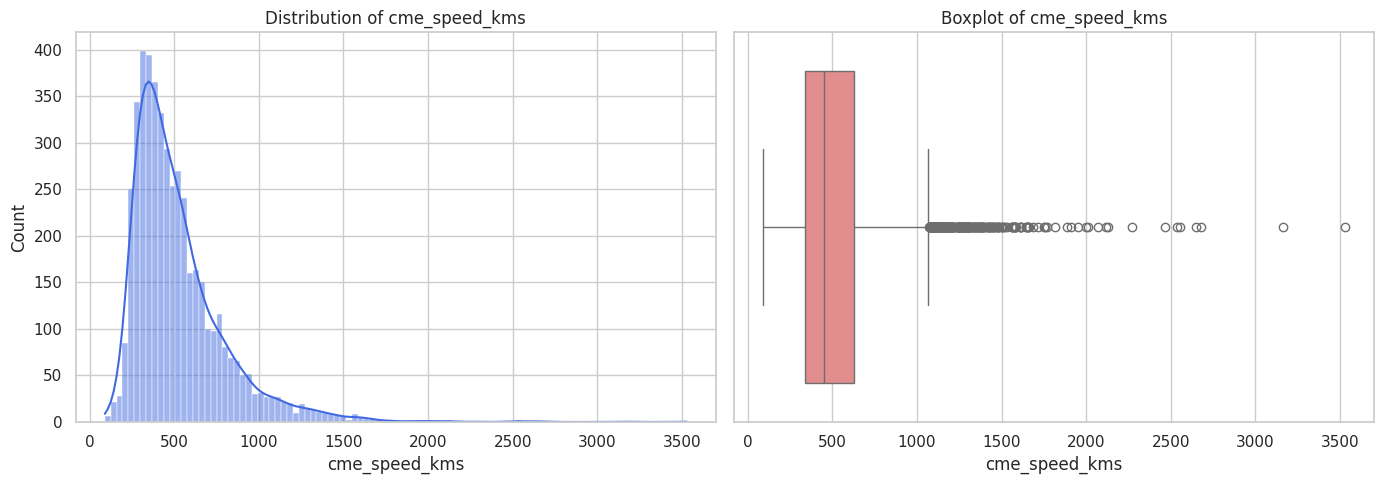

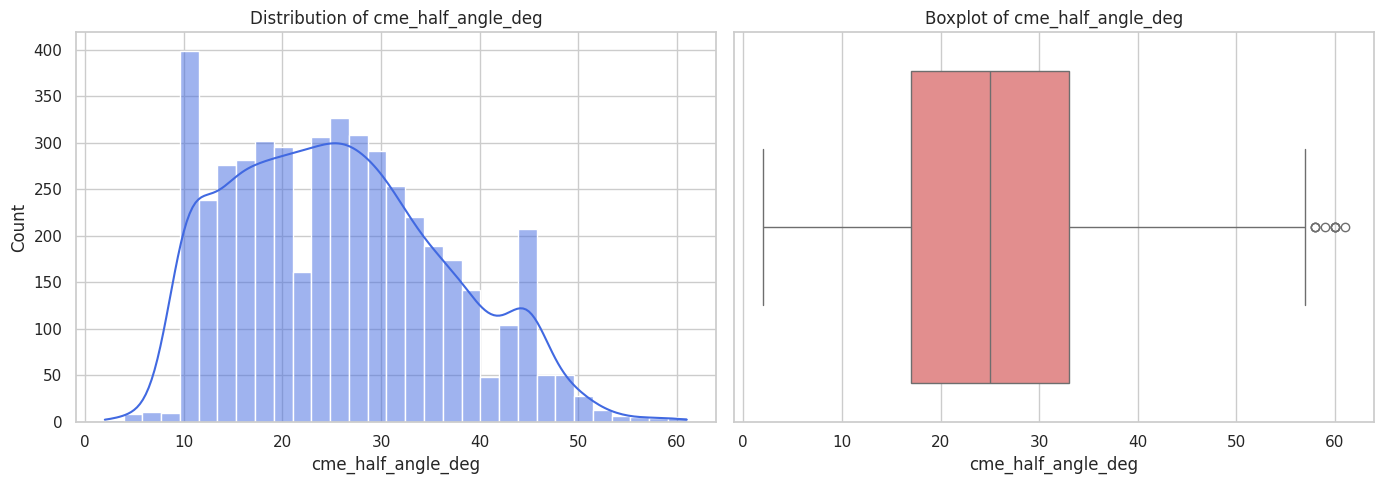

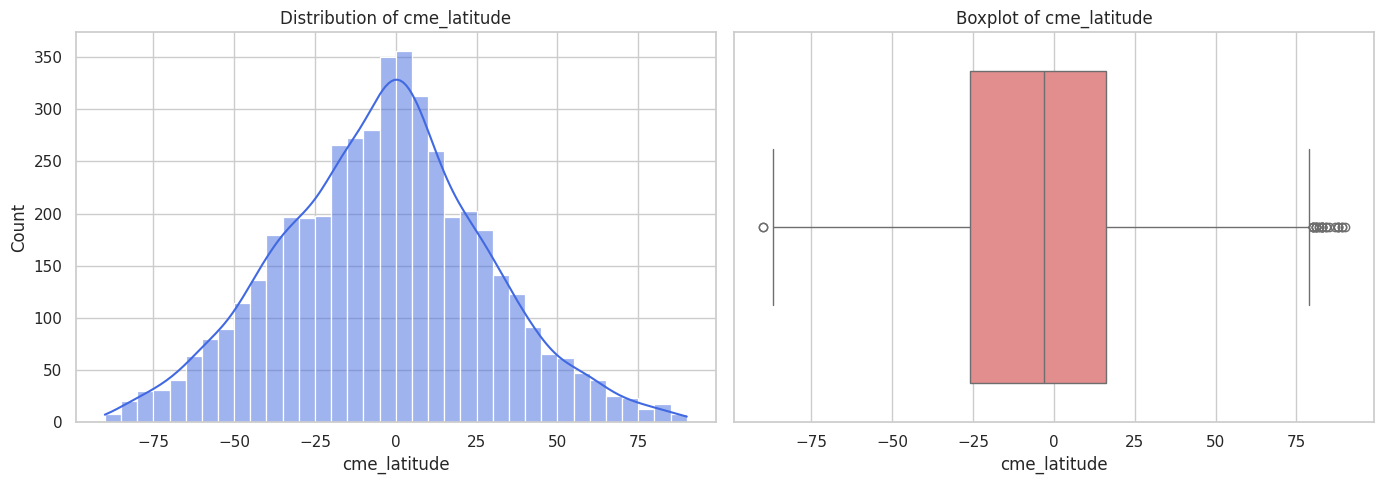

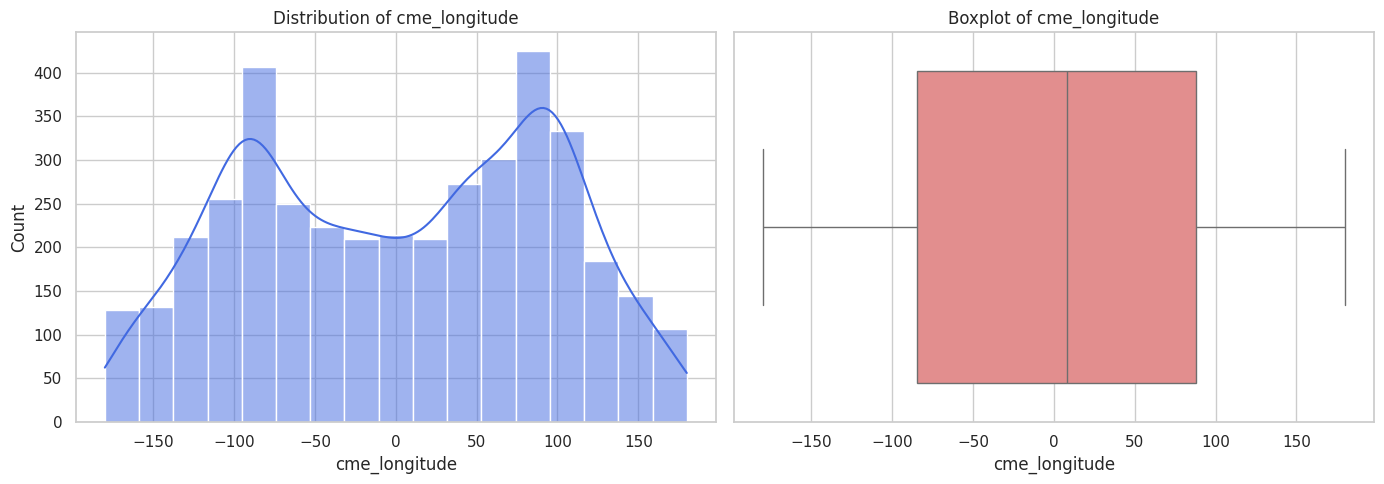

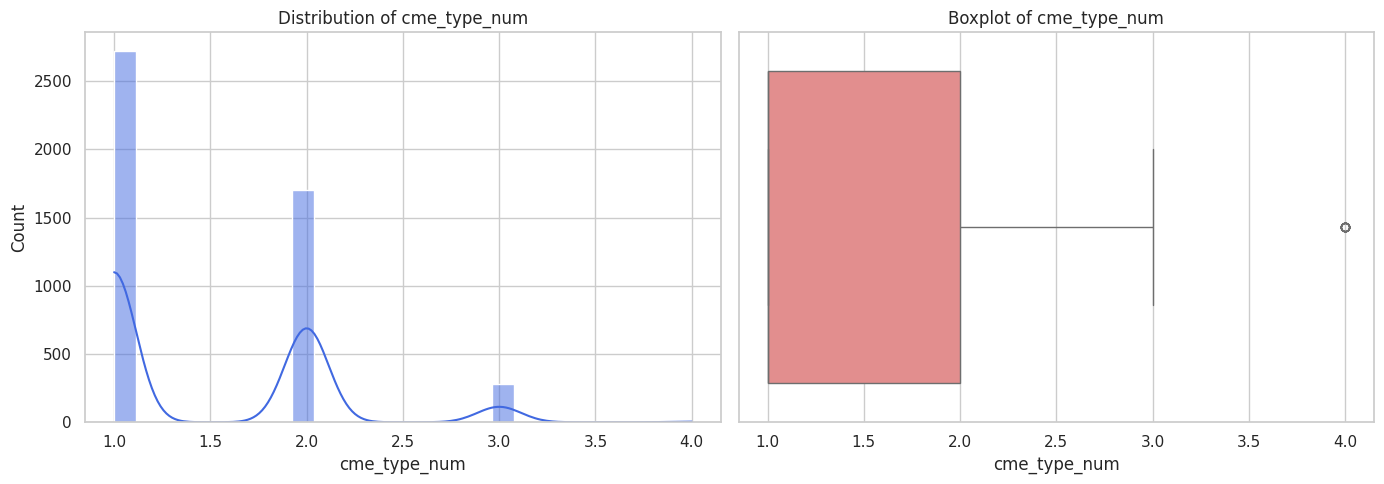

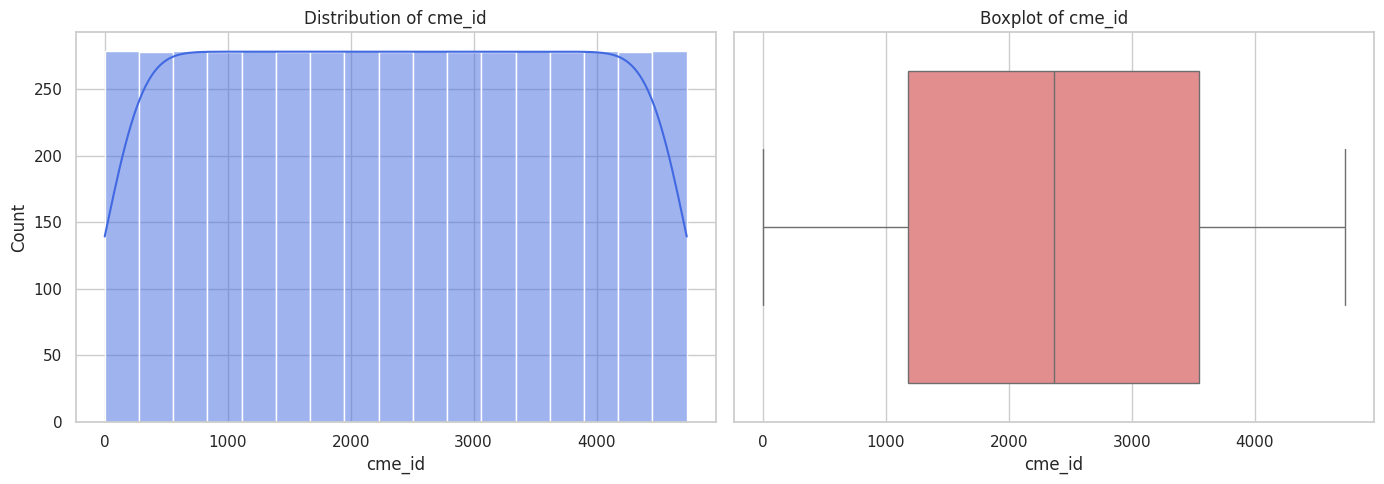

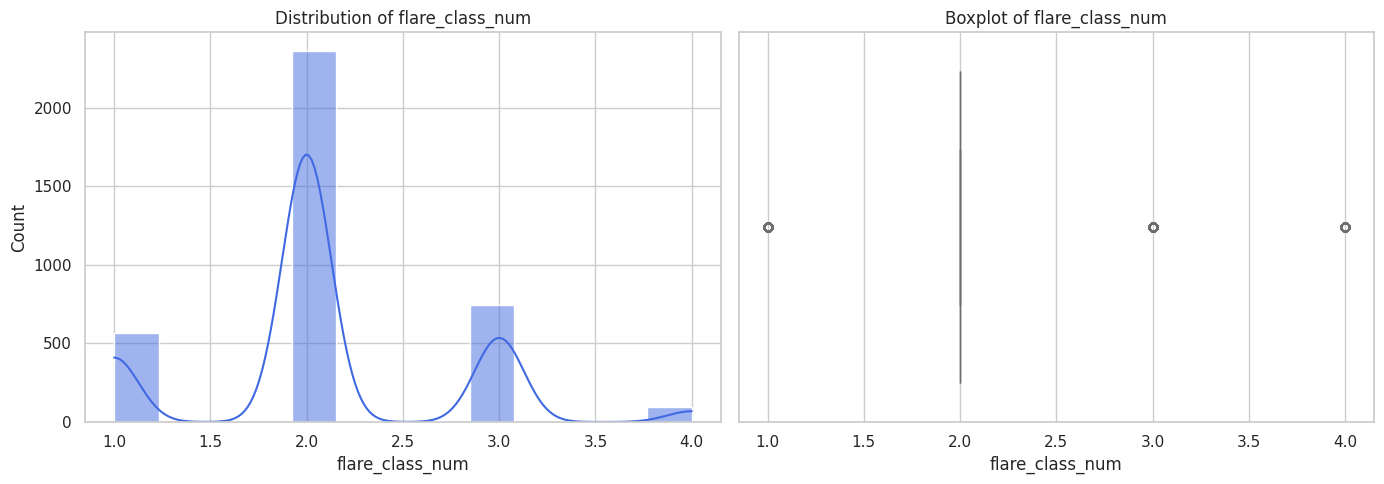

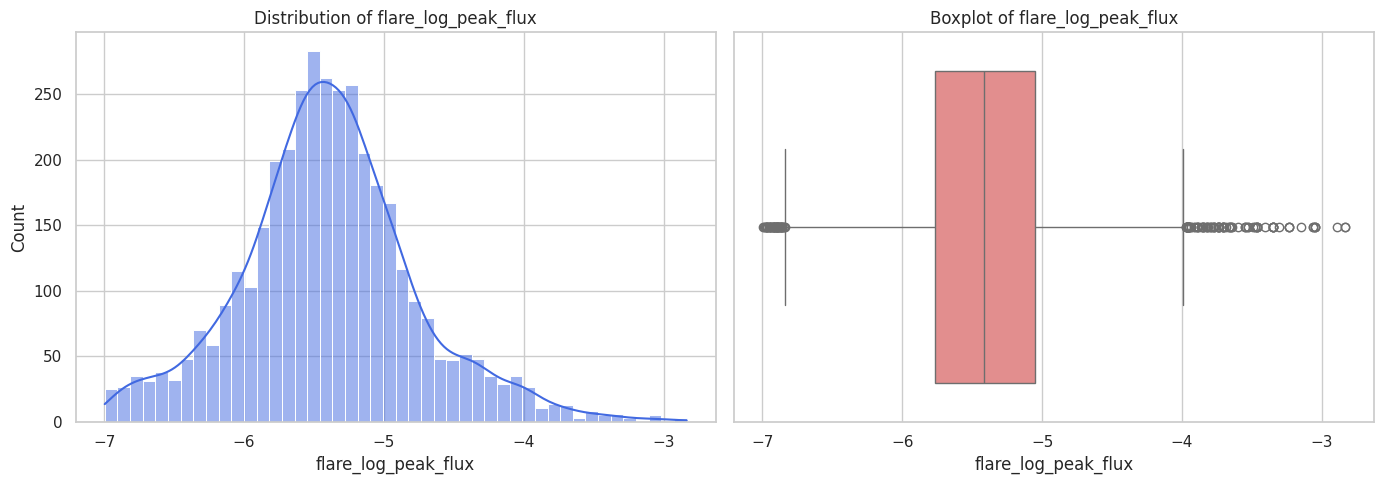

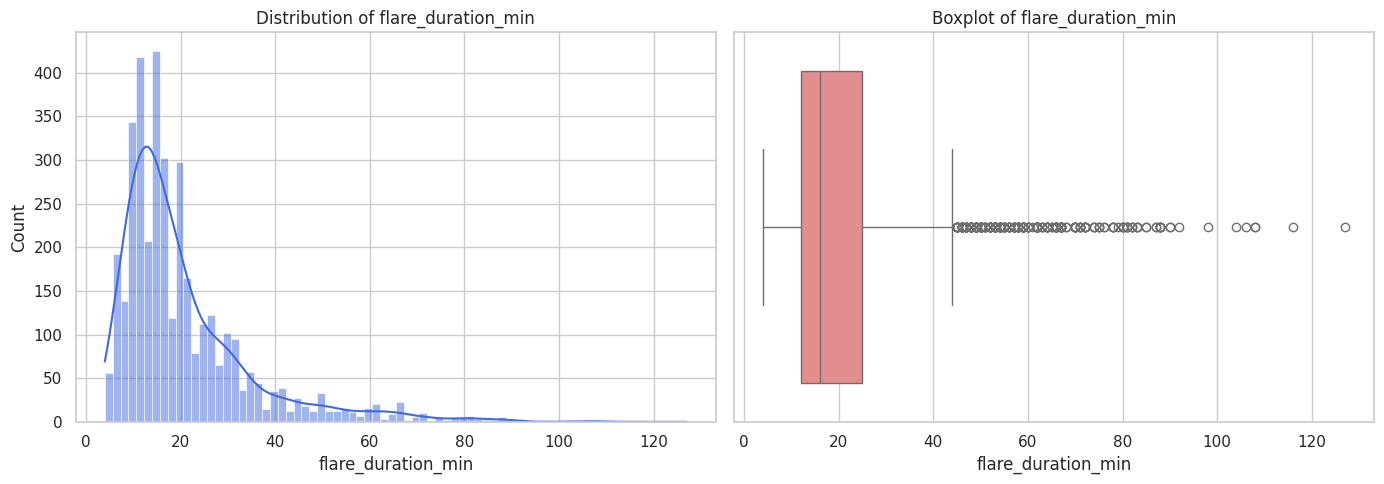

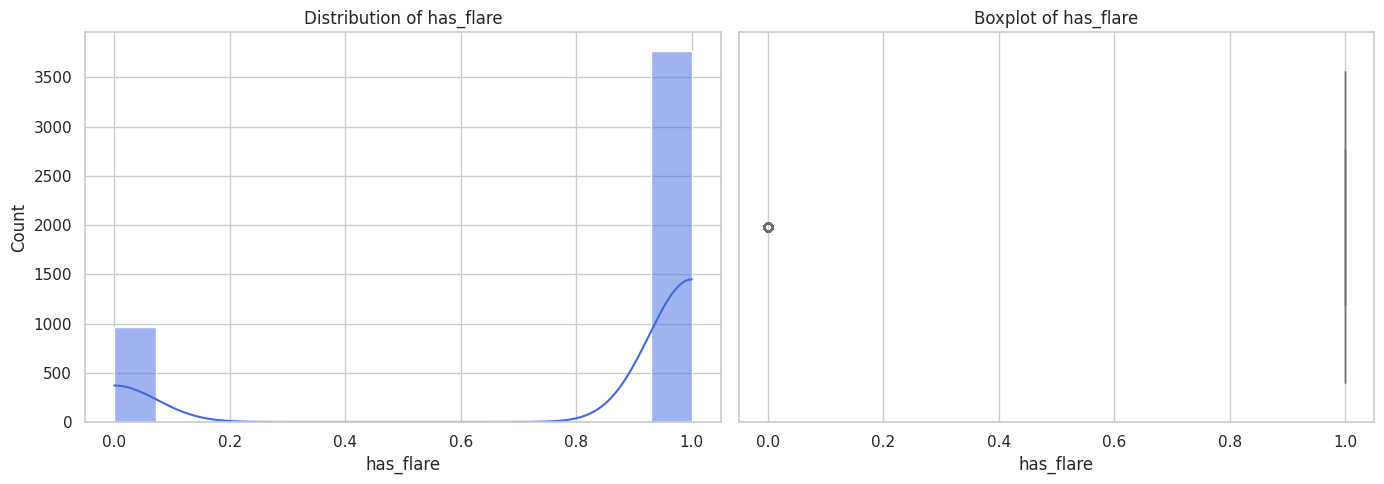

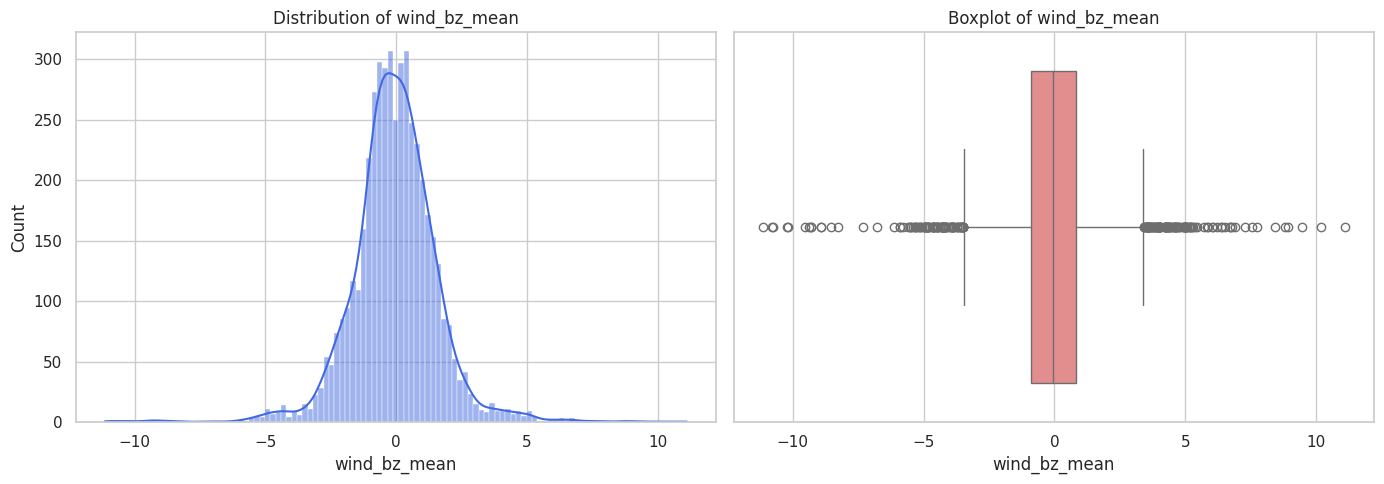

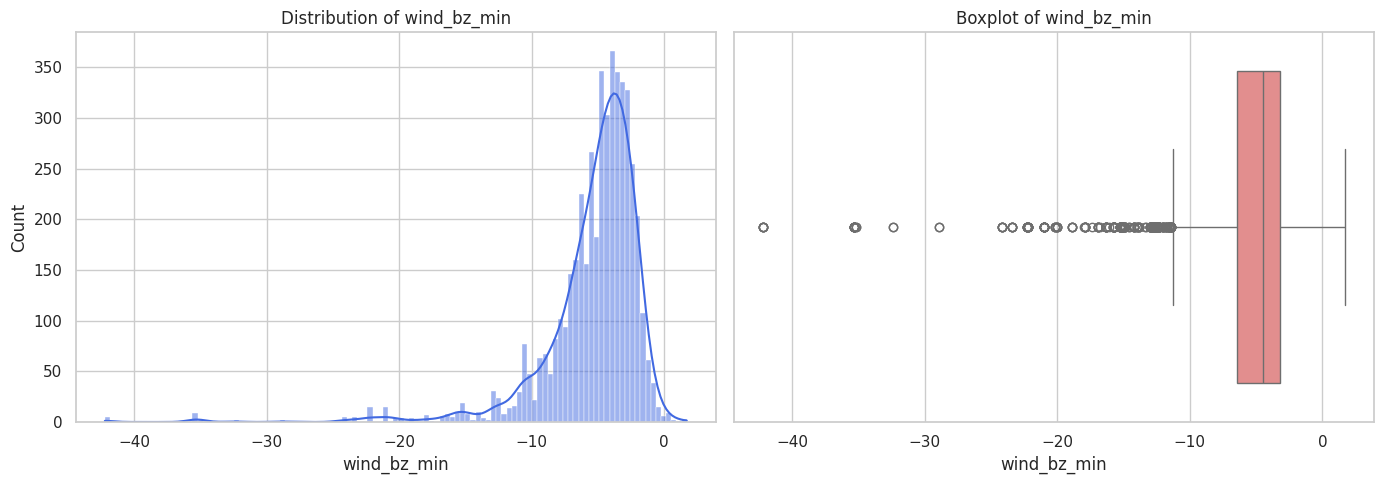

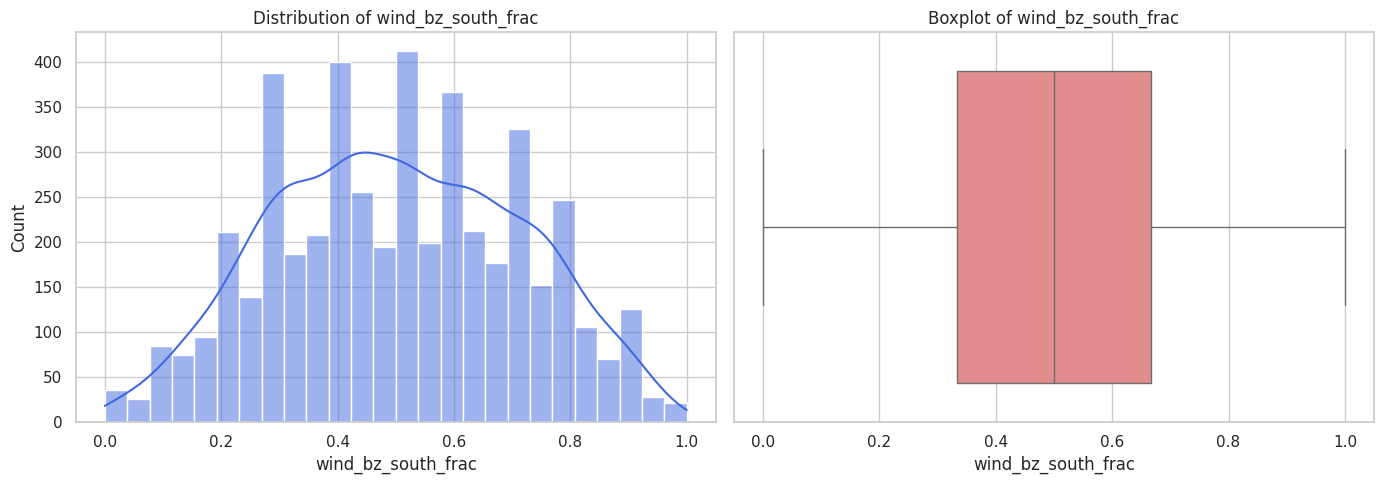

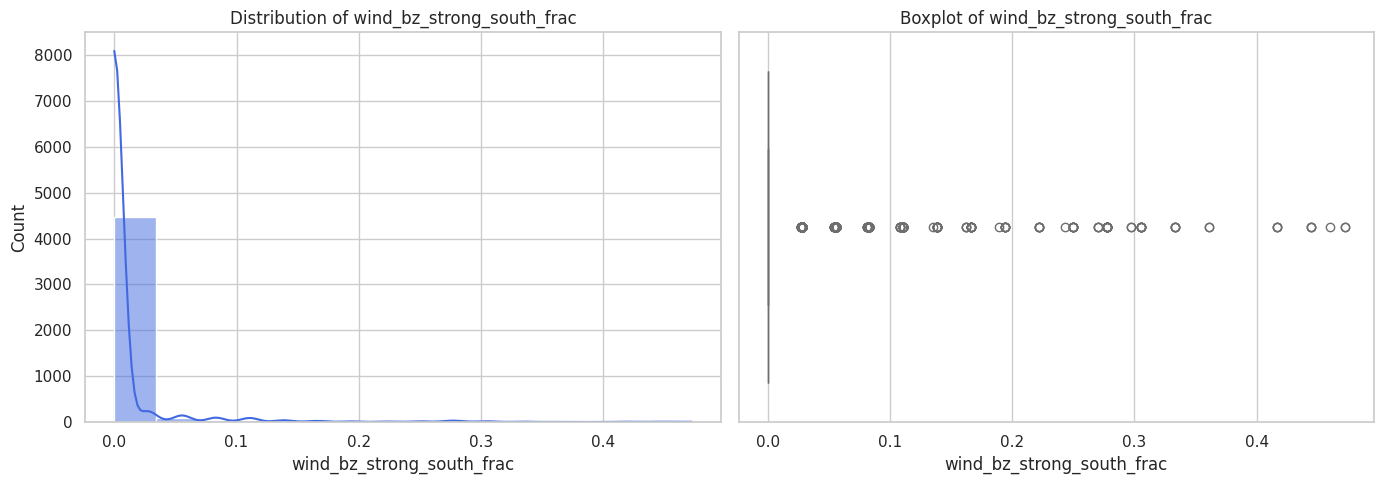

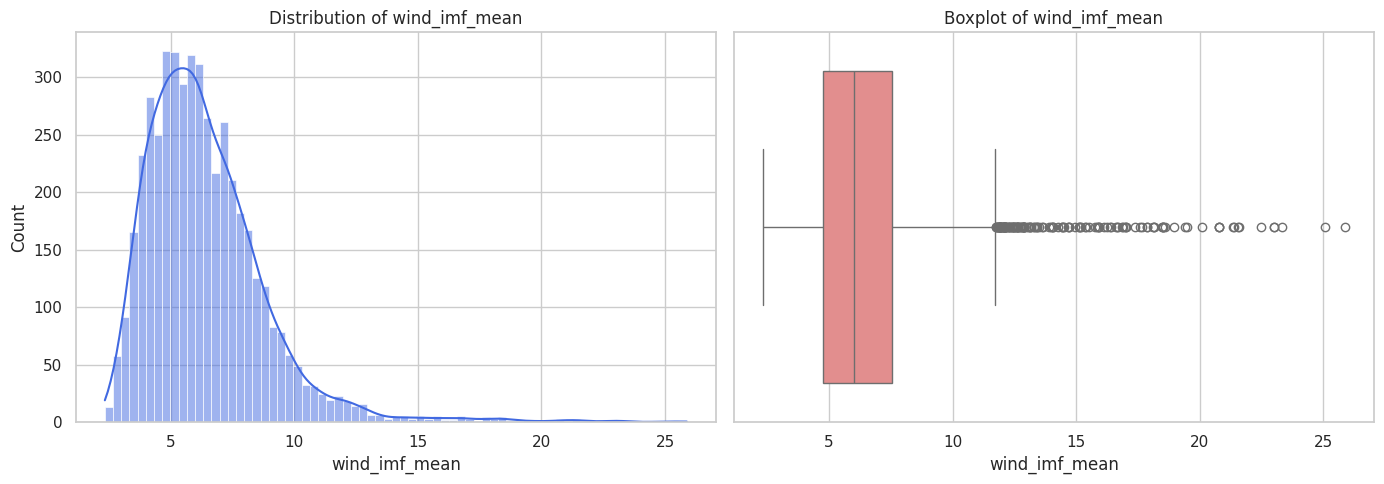

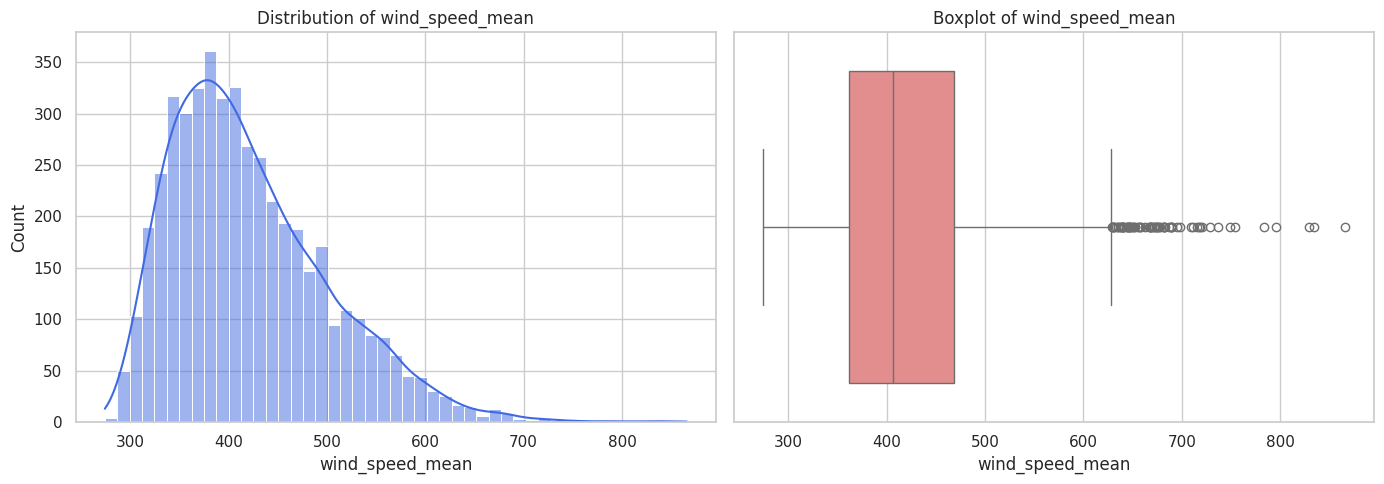

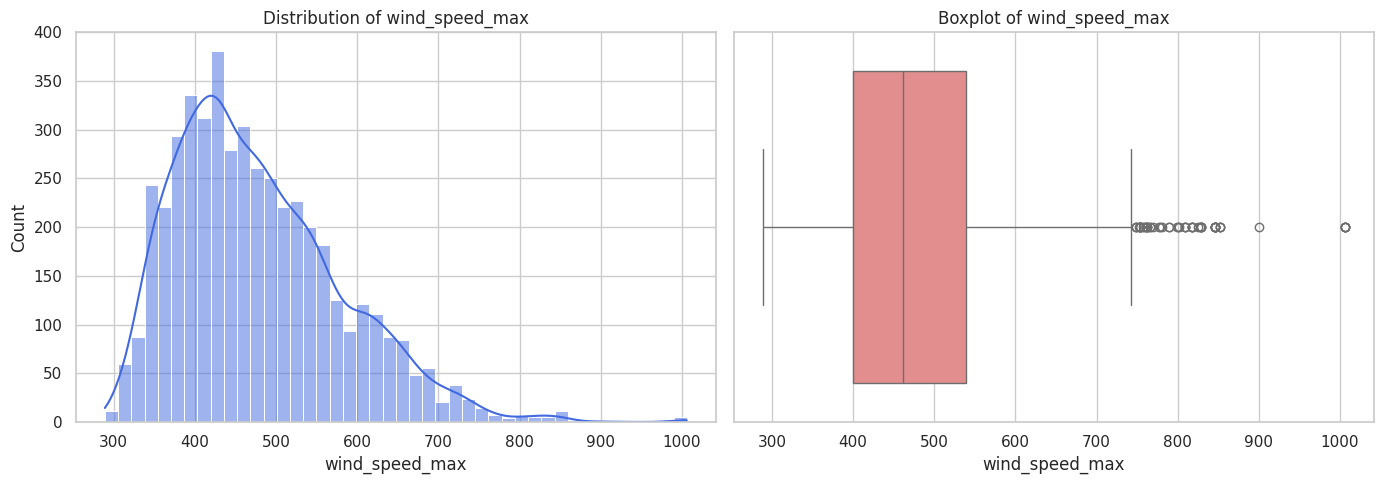

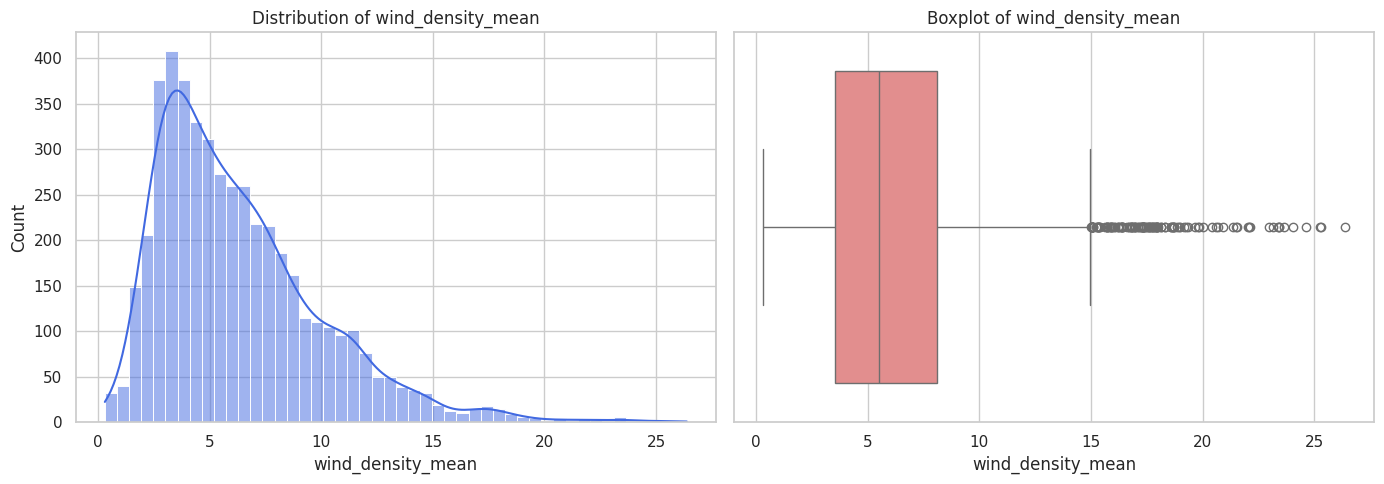

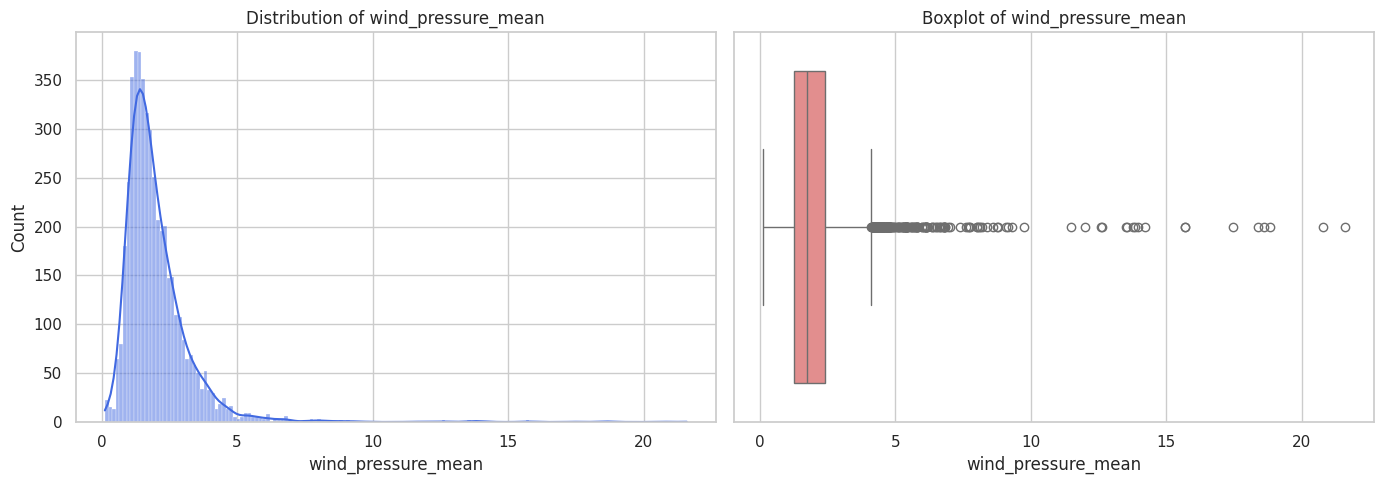

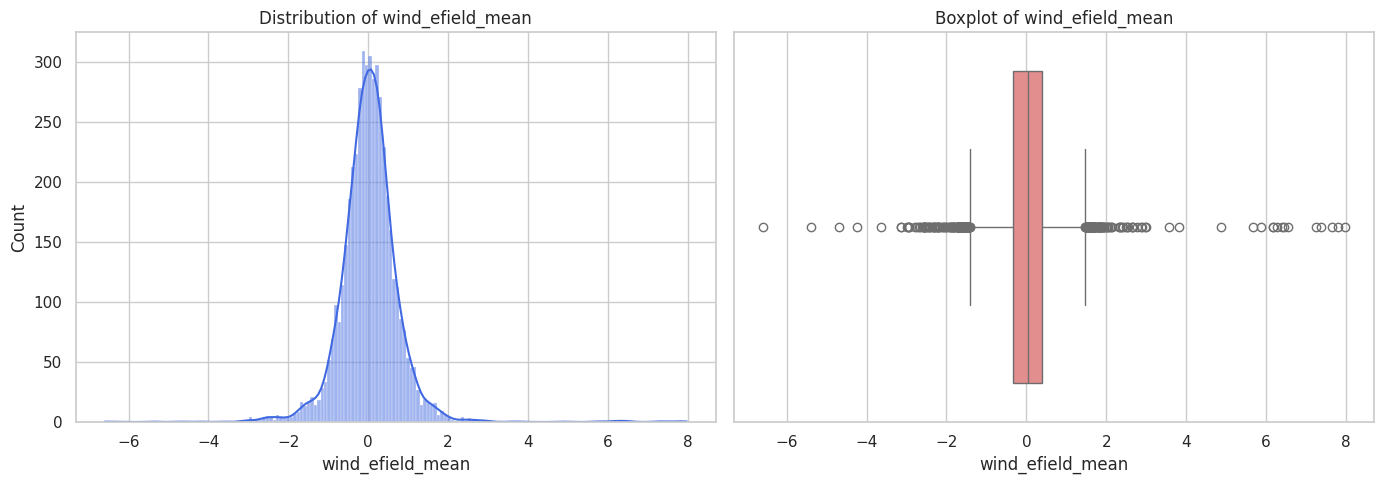

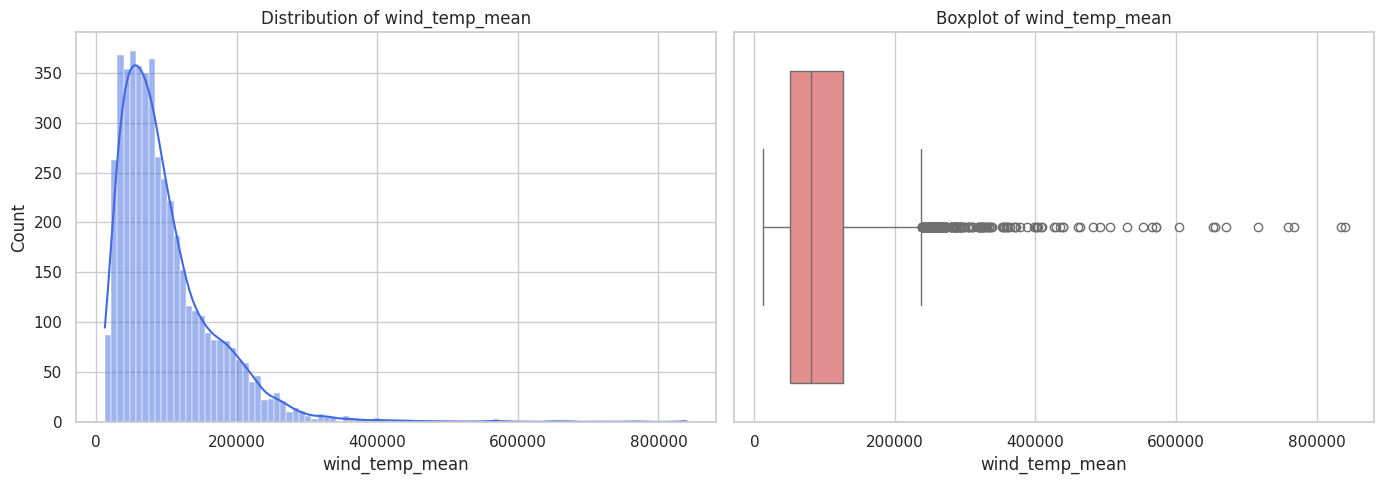

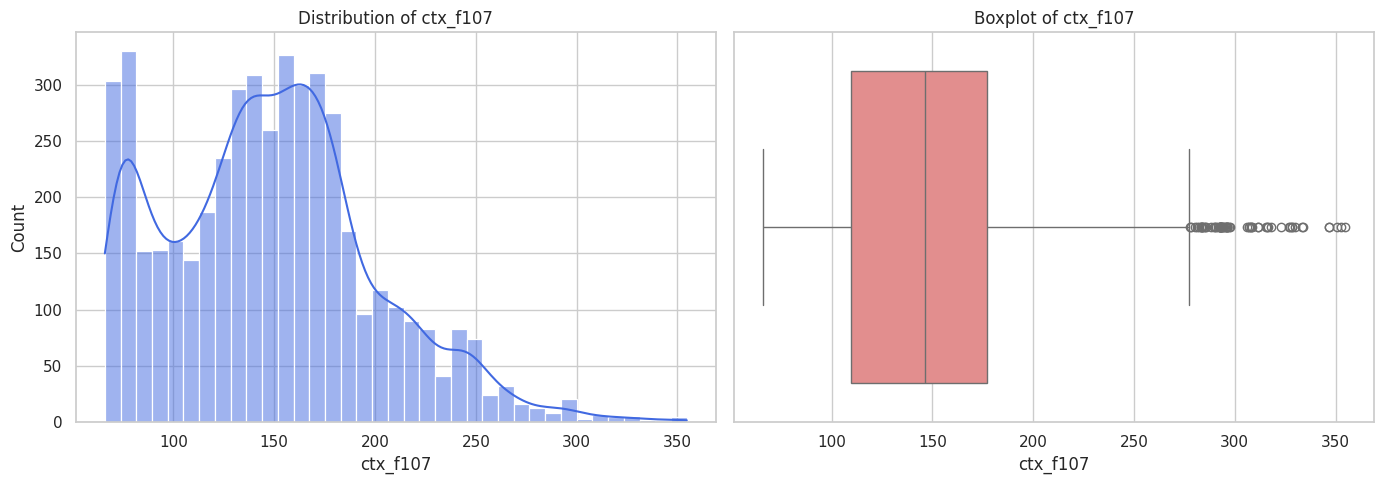

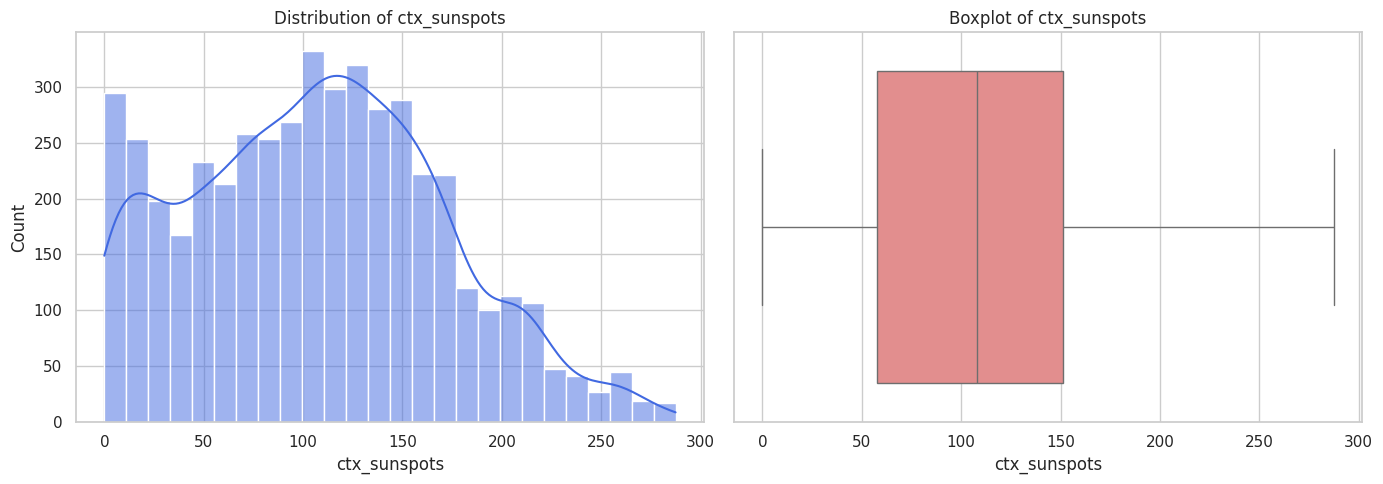

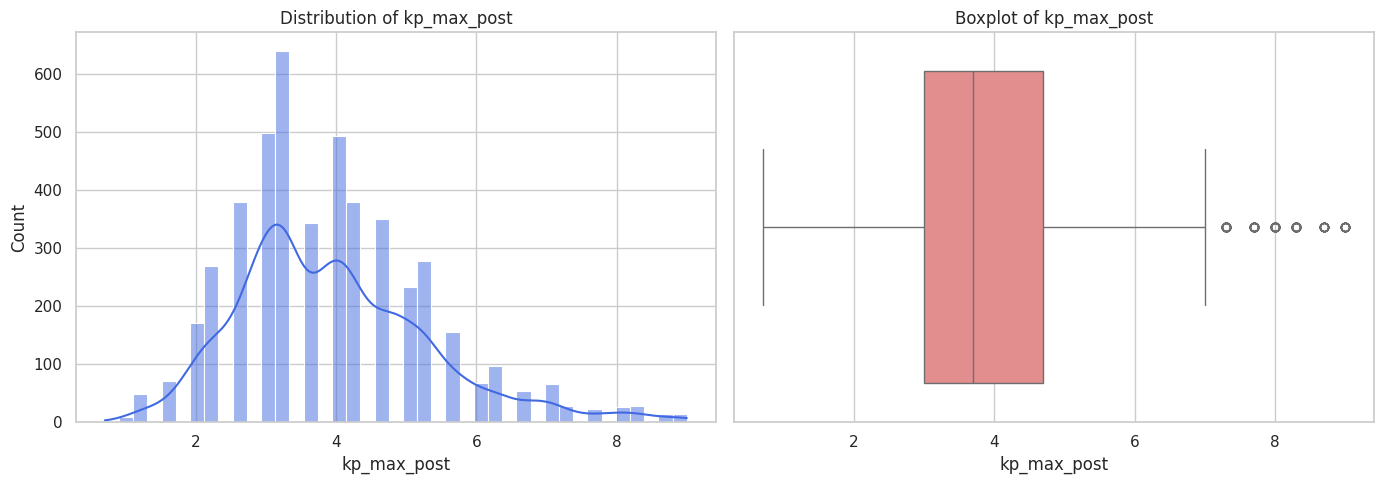

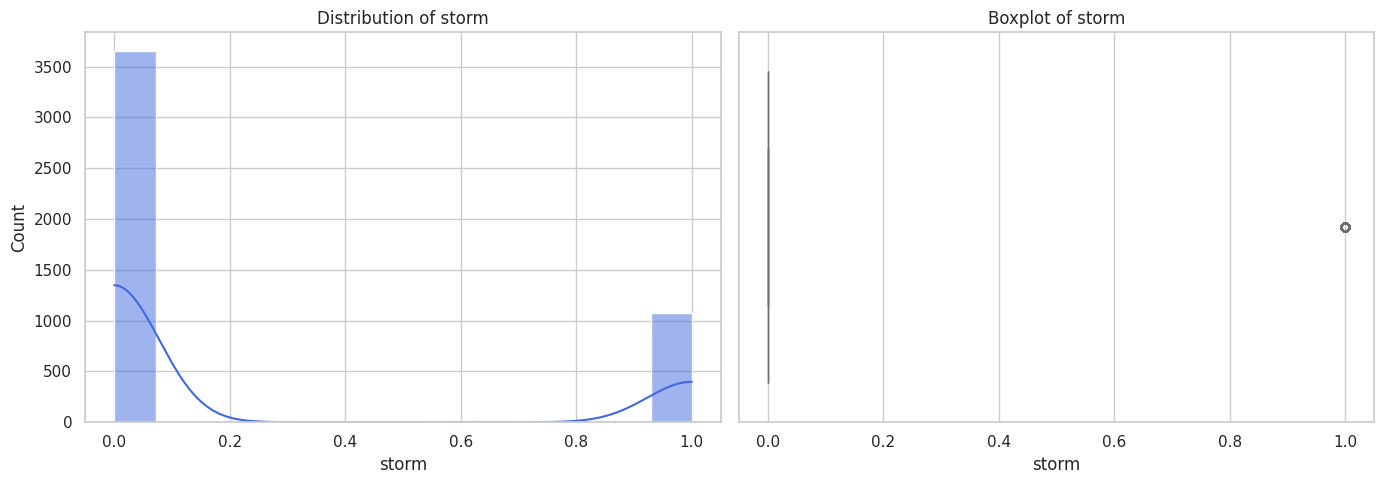

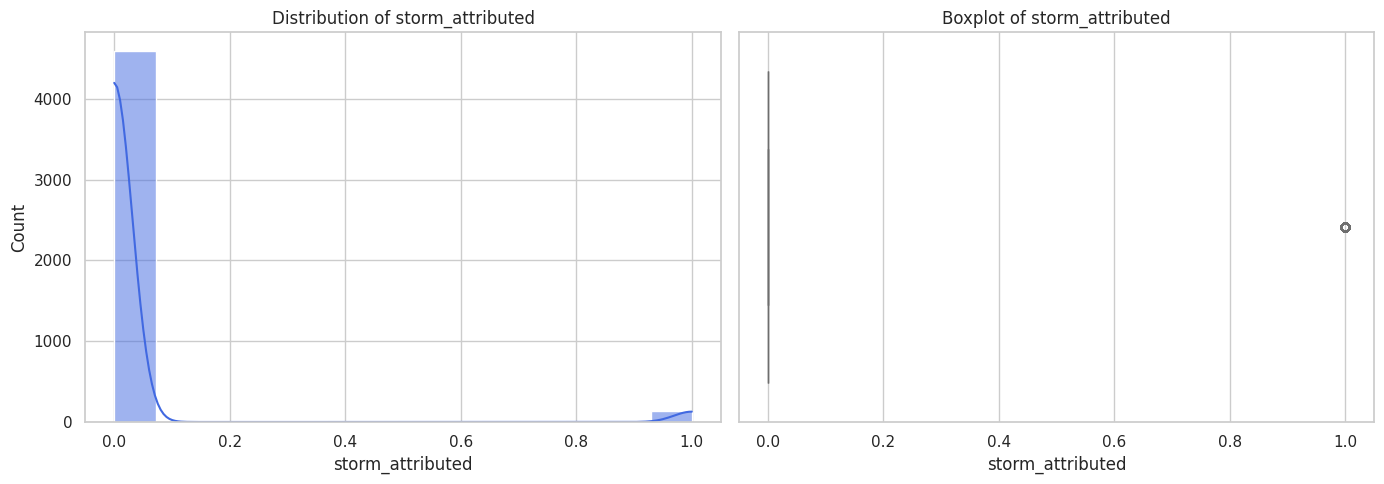

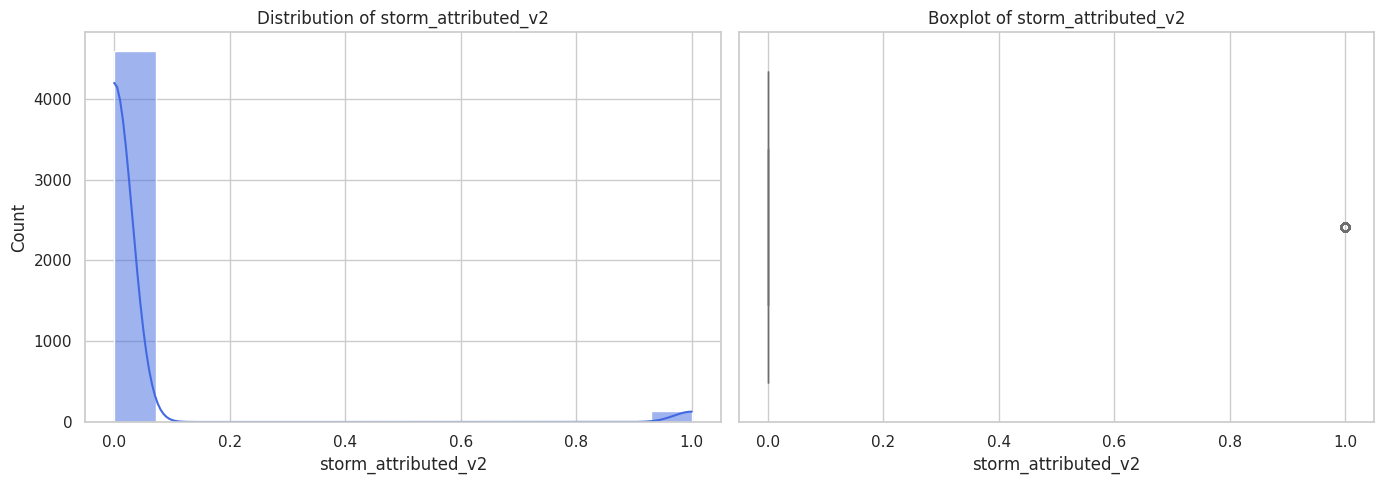

In [7]:
# Identify numerical columns for tracking physics properties
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram / KDE
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color='royalblue')
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)

    # Boxplot to see outliers
    sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

### CME Type / Halo Classification
CMEs are often classified by their angular width or type (e.g., Full Halo, Partial Halo). Let's see the frequency breakdown if these categorical classifications exist.

/tmp/ipykernel_5939/973016992.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


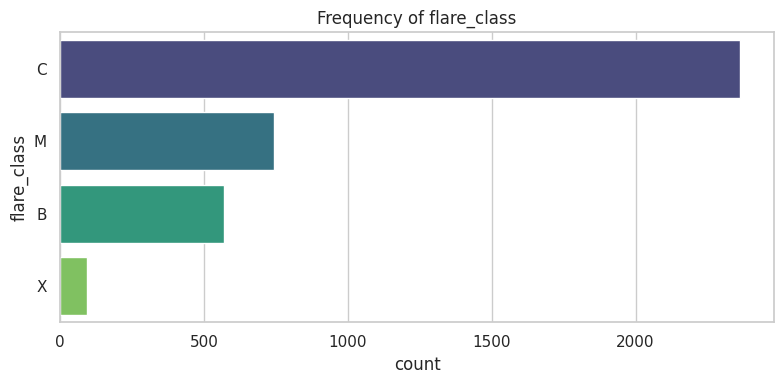

In [8]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_cols:
    # Limit to unique values to keep charts readable
    if df[col].nunique() < 15:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Frequency of {col}')
        plt.tight_layout()
        plt.show()

## 4. Temporal Trends
Solar activity follows an approximate 11-year solar cycle. Let's see how the frequency and intensity of CMEs trend over time in our dataset.

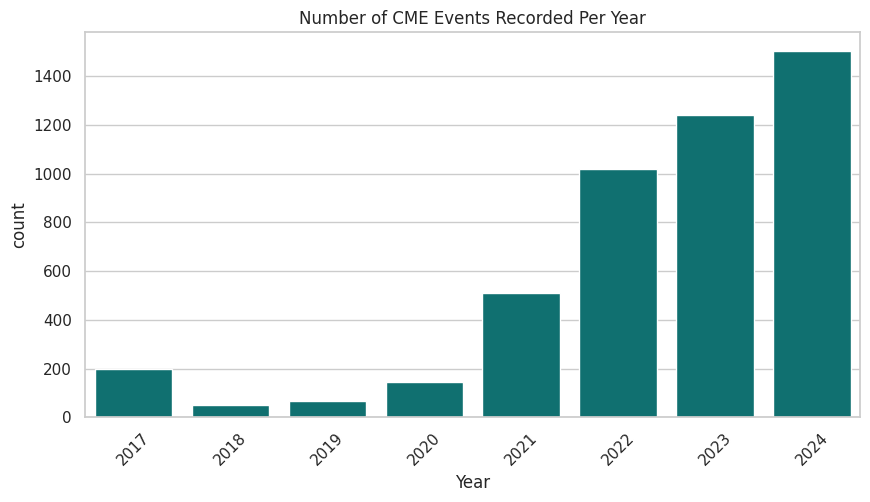

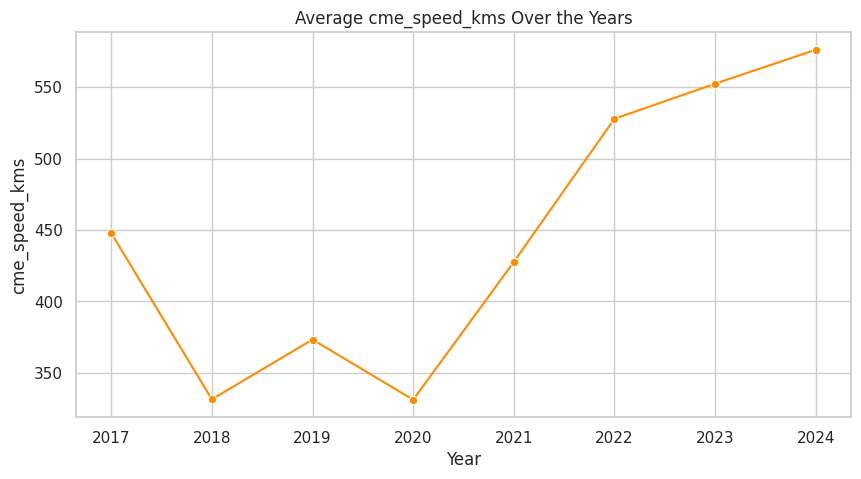

In [9]:
if len(time_cols) > 0:
    primary_time = time_cols[0]
    df['Year'] = df[primary_time].dt.year

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df.dropna(subset=['Year']), x='Year', color='teal')
    plt.title('Number of CME Events Recorded Per Year')
    plt.xticks(rotation=45)
    plt.show()

    speed_cols = [col for col in df.columns if 'speed' in col.lower()]
    if len(speed_cols) > 0:
        plt.figure(figsize=(10, 5))
        sns.lineplot(data=df, x='Year', y=speed_cols[0], estimator='mean', errorbar=None, marker='o', color='darkorange')
        plt.title(f'Average {speed_cols[0]} Over the Years')
        plt.show()

## 5. Feature Inter-relationships
Understanding the correlation between properties like Speed, Mass, and Half-Angle helps determine what characteristics usually appear together during powerful eruptions.

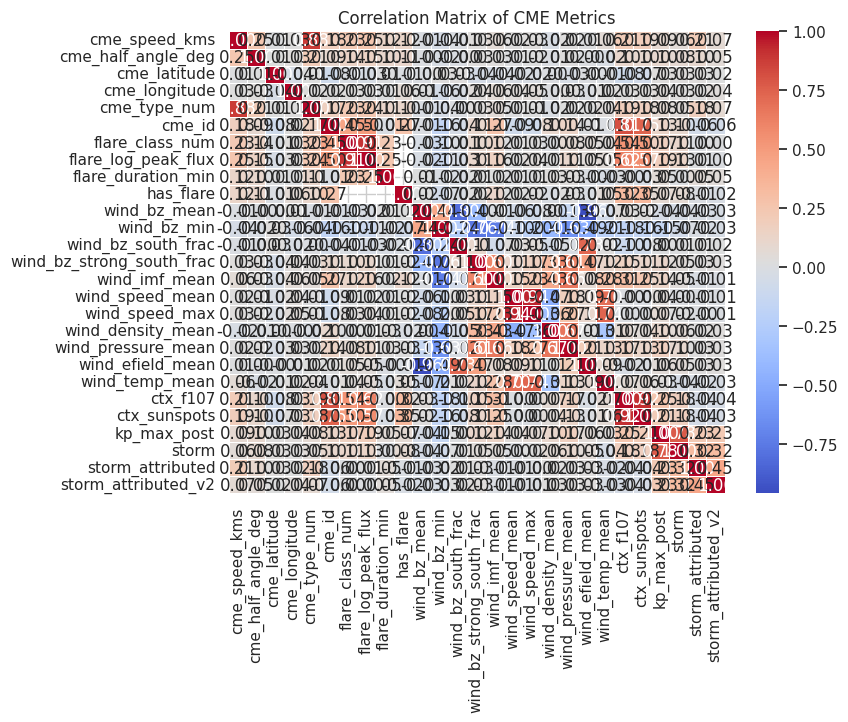

In [10]:
if len(numerical_cols) > 1:
    plt.figure(figsize=(8, 6))
    corr = df[numerical_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix of CME Metrics')
    plt.show()

## 6. Key Takeaways & Next Steps
* **Data Quality**: Document anomalies, missing data ratios, and flag values encountered.
* **Feature Engineering**: Consider calculating time deltas if multiple observation points are given.
* **Predictor Integration**: Ready to merge with the `space-weather-indices` dataset (e.g., Kp/Dst indexes) based on calculated arrival windows to see true storm correlations.